# Consumer Complaint Classification

## 1. Import Libraries

In [7]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import tensorflow as tf
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout,
    SpatialDropout1D
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


## 2. Load Preprocessed Data

In [8]:
base_path = "/kaggle/input/datasets/mohamedafifi77/files"

 
X_train = np.load(os.path.join(base_path, "X_train.npy"))
X_test = np.load(os.path.join(base_path, "X_test.npy"))

y_train = np.load(os.path.join(base_path, "y_train.npy"))
y_test = np.load(os.path.join(base_path, "y_test.npy"))

 
with open(os.path.join(base_path, "label_encoder.pkl"), "rb") as f:
    label_encoder = pickle.load(f)

with open(os.path.join(base_path, "tokenizer.pkl"), "rb") as f:
    tokenizer = pickle.load(f)

 

## 3. Build LSTM  Model

In [9]:
VOCAB_SIZE = 20000
MAX_LEN = 240

EMBEDDING_DIM = 128

RNN_UNITS = 128

DENSE_UNITS = 64

DROPOUT_RATE = 0.5

BATCH_SIZE = 128

EPOCHS = 20

NUM_CLASSES = len(label_encoder.classes_)

In [10]:
model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        mask_zero=True
    ),

    SpatialDropout1D(0.2),

    LSTM(

        RNN_UNITS,

        dropout=0.2,

        recurrent_dropout=0.2

    ),

    Dense(
        DENSE_UNITS,
        activation="relu"
    ),

    Dropout(DROPOUT_RATE),

    Dense(
        NUM_CLASSES,
        activation="softmax"
    )

])

model.build(input_shape=(None, MAX_LEN))

model.summary()

I0000 00:00:1784472332.023822      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784472332.030181      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 240, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 240, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,700,165 (10.30 MB)

 Trainable params: 2,700,165 (10.30 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [12]:
early_stop = EarlyStopping(

    monitor="val_loss",

    patience=3,

    restore_best_weights=True,

    verbose=1

)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=2,

    verbose=1

)

checkpoint = ModelCheckpoint(

    "/kaggle/working/best_lstm.keras",

    monitor="val_accuracy",

    save_best_only=True,

    verbose=1

)

## 4. Train Model

In [13]:
history = model.fit(

    X_train,

    y_train,

    validation_data=(X_test, y_test),

    epochs=EPOCHS,

    batch_size=BATCH_SIZE,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ],

    verbose=1

)

Epoch 1/20
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 0s 910ms/step - accuracy: 0.7001 - loss: 0.8162
Epoch 1: val_accuracy improved from None to 0.83942, saving model to /kaggle/working/best_lstm.keras

Epoch 1: finished saving model to /kaggle/working/best_lstm.keras
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 976s 953ms/step - accuracy: 0.7655 - loss: 0.6666 - val_accuracy: 0.8394 - val_loss: 0.4947 - learning_rate: 0.0010
Epoch 2/20
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 0s 911ms/step - accuracy: 0.8438 - loss: 0.5018
Epoch 2: val_accuracy improved from 0.83942 to 0.86079, saving model to /kaggle/working/best_lstm.keras

Epoch 2: finished saving model to /kaggle/working/best_lstm.keras
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 969s 954ms/step - accuracy: 0.8466 - loss: 0.4893 - val_accuracy: 0.8608 - val_loss: 0.4159 - learning_rate: 0.0010
Epoch 3/20
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 0s 911ms/step - accuracy: 0.8644 - loss: 0.4260
Epoch 3: val_accuracy improved from 0.86079 to 0.86642, saving model to /kaggle/working/best_lstm

## 5. Evaluate Model

In [14]:
# Predictions
y_pred_prob = model.predict(X_test)

y_pred = np.argmax(y_pred_prob, axis=1)

1016/1016 ━━━━━━━━━━━━━━━━━━━━ 168s 165ms/step


In [15]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="macro"
)

recall = recall_score(
    y_test,
    y_pred,
    average="macro"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.8821
Precision: 0.8456
Recall   : 0.8488
F1 Score : 0.8469


In [16]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

                     precision    recall  f1-score   support

        credit_card       0.80      0.77      0.79      3113
   credit_reporting       0.93      0.93      0.93     18235
    debt_collection       0.80      0.80      0.80      4630
mortgages_and_loans       0.85      0.84      0.85      3798
     retail_banking       0.85      0.91      0.88      2707

           accuracy                           0.88     32483
          macro avg       0.85      0.85      0.85     32483
       weighted avg       0.88      0.88      0.88     32483



## 6. Visualize Results

<Figure size 800x800 with 0 Axes>

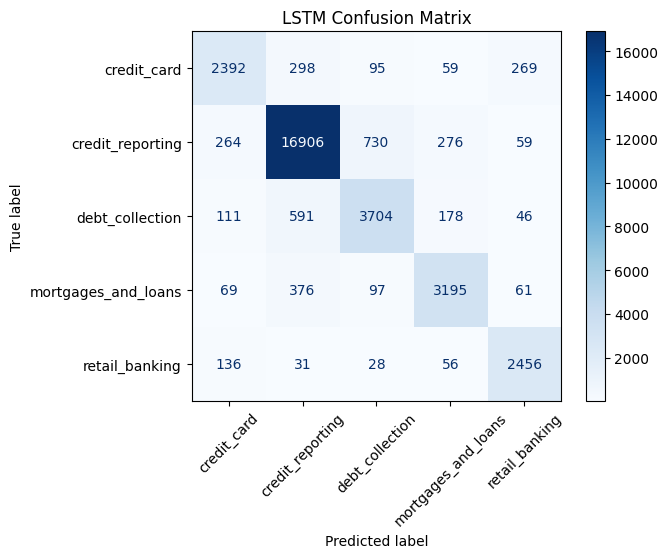

In [17]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

plt.figure(figsize=(8,8))

disp.plot(
    cmap="Blues",
    xticks_rotation=45
)

plt.title("LSTM Confusion Matrix")

plt.show()

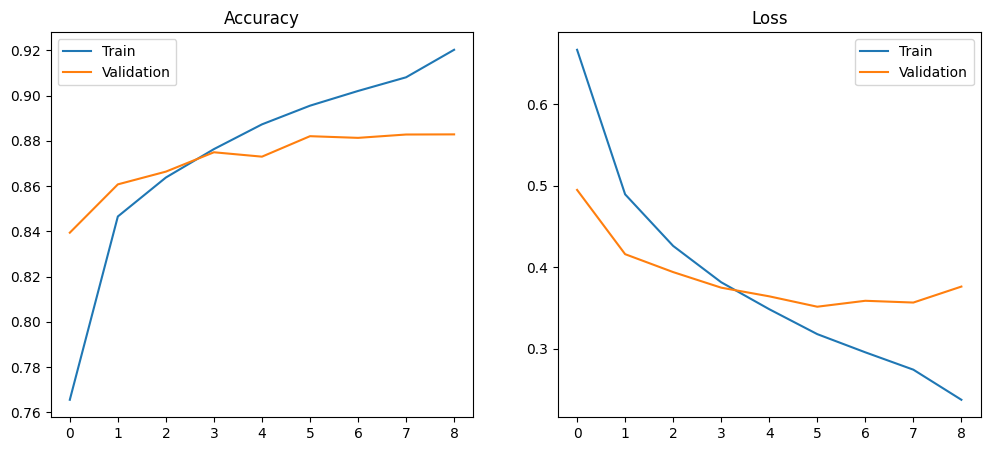

In [18]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history["accuracy"], label="Train")

plt.plot(history.history["val_accuracy"], label="Validation")

plt.title("Accuracy")

plt.legend()

plt.subplot(1,2,2)

plt.plot(history.history["loss"], label="Train")

plt.plot(history.history["val_loss"], label="Validation")

plt.title("Loss")

plt.legend()

plt.show()

## 7. Save 

In [19]:
with open("/kaggle/working/lstm_history.pkl","wb") as f:
    pickle.dump(history.history,f)

In [22]:
results = pd.DataFrame({
    "Model":["LSTM"],
    "Accuracy":[accuracy],
    "Macro Precision":[precision],
    "Macro Recall":[recall],
    "Macro F1":[f1]
})

results.to_csv("/kaggle/working/lstm_results.csv",index=False)